## Applying K-Means Algorithm on titanic dataset

In [1]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import pandas as pd
import seaborn as sns


In [2]:
df = sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [18]:
df = df[['age','fare','pclass']]

In [19]:
df.head()

,age,fare,pclass
0,22.0,7.2500,3
1,38.0,71.2833,1
2,26.0,7.9250,3
3,35.0,53.1000,1
4,35.0,8.0500,3


In [ ]:

# select features
features = df[['age','fare','pclass']].dropna()

# scale data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(features)


In [29]:
df1 = df[['age','fare','pclass']].dropna().copy()

In [15]:
features.shape,scaled_data.shape

((714, 3), (714, 3))

In [30]:

# apply KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
df1['Cluster'] = kmeans.fit_predict(scaled_data).reshape(-1,1)

In [31]:
df1

,age,fare,pclass,Cluster
0,22.0,7.2500,3,2
1,38.0,71.2833,1,1
2,26.0,7.9250,3,2
3,35.0,53.1000,1,1
4,35.0,8.0500,3,2
...,...,...,...,...
885,39.0,29.1250,3,2
886,27.0,13.0000,2,2
887,19.0,30.0000,1,1
889,26.0,30.0000,1,1


In [36]:
df.groupby('Cluster')['survived'].mean()

KeyError: 'Cluster'

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(df1['Age'], df1['Fare'], 
            c=features['Cluster'], cmap='viridis')

plt.xlabel('Age')
plt.ylabel('Fare')
plt.title('K-Means Clusters (Age vs Fare)')

plt.colorbar(label='Cluster')
plt.show()

KeyError: 'Age'

<Figure size 800x600 with 0 Axes>

In [3]:
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [30]:
new_df = df[['age','fare','survived','pclass']].dropna()

In [31]:
new_df.isnull().sum()

age         0
fare        0
survived    0
pclass      0
dtype: int64

In [39]:
X = new_df.iloc[:,:2]
y = new_df.iloc[:,2]

In [40]:
X,y

(      age     fare
 0    22.0   7.2500
 1    38.0  71.2833
 2    26.0   7.9250
 3    35.0  53.1000
 4    35.0   8.0500
 ..    ...      ...
 885  39.0  29.1250
 886  27.0  13.0000
 887  19.0  30.0000
 889  26.0  30.0000
 890  32.0   7.7500
 
 [714 rows x 2 columns],
 0      0
 1      1
 2      1
 3      1
 4      0
       ..
 885    0
 886    0
 887    1
 889    1
 890    0
 Name: survived, Length: 714, dtype: int64)

In [41]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

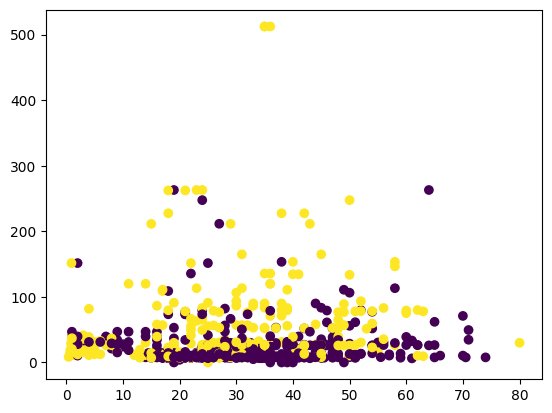

In [42]:
plt.scatter(X.iloc[:,0],X.iloc[:,1],c=y)

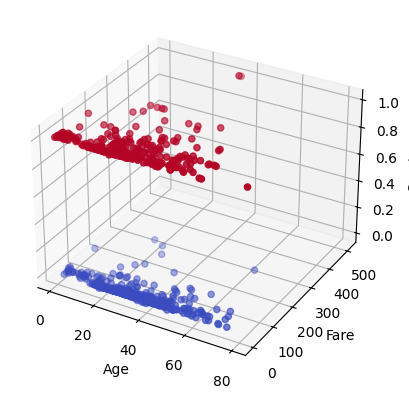

In [44]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # needed for 3D plots

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    X.iloc[:, 0],   # Age
    X.iloc[:, 1],   # Fare
    y,              # Survived (Z-axis)
    c=y,            # color by survival
    cmap='coolwarm'
)

ax.set_xlabel('Age')
ax.set_ylabel('Fare')
ax.set_zlabel('Survived')

plt.show()


In [45]:
wcss = []

for i in range(1,15):
    kmean = KMeans(n_clusters=i,init='k-means++')
    kmean.fit(X)
    wcss.append(kmean.inertia_)

In [46]:
wcss

[2147151.176026778,
 917395.1498096412,
 510901.04900943243,
 314634.1364151311,
 242600.93874494982,
 194954.91999095507,
 126092.83651815653,
 113421.63181468981,
 100640.66509939011,
 86329.47638533088,
 82292.70410731909,
 71933.96959196588,
 61815.15101405882,
 65376.25425633462]

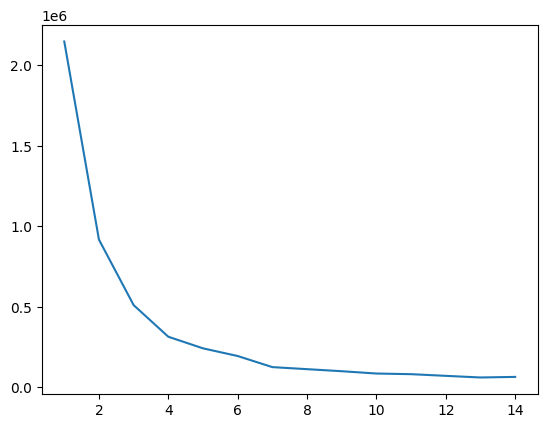

In [50]:
plt.plot(range(1,15),wcss)

In [52]:
kmean = KMeans(n_clusters=4,init='k-means++')
pred = kmean.fit_predict(X)

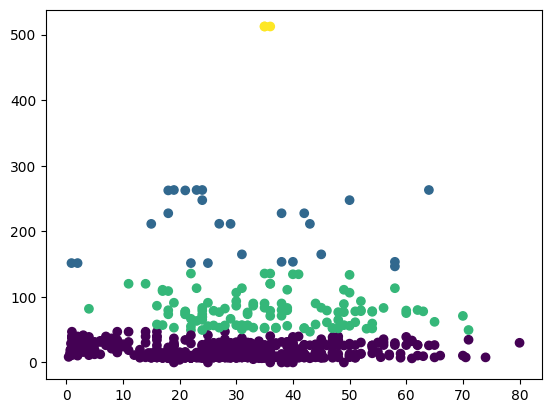

In [53]:
plt.scatter(X.iloc[:,0],X.iloc[:,1],c=pred)

In [61]:
## prediction on new data
import warnings
warnings.filterwarnings('ignore')
kmean.predict([[10,200]])

array([1], dtype=int32)

In [67]:
!pip install kneed

In [69]:
## validating number of cluster with:
# neelocator 
# silhoutte scoring

from kneed import KneeLocator

In [70]:
knee = KneeLocator(range(1,15),wcss,curve='convex',direction='decreasing')

In [75]:
knee.elbow

np.int64(4)

In [76]:
from sklearn.metrics import silhouette_score

In [77]:
## now we apply silhoutte scoring 
silhoutte_coefficients=[]
for k in range(2,15):
    kmeans = KMeans(n_clusters=k,init='k-means++')
    kmeans.fit(X)
    score = silhouette_score(X,kmeans.labels_)
    silhoutte_coefficients.append(score)
    

In [78]:
silhoutte_coefficients

[0.899790003031232,
 0.7005584967028491,
 0.4245486600209878,
 0.4859292573188487,
 0.4339547926802931,
 0.45998219377167715,
 0.456282462854128,
 0.4543289074570837,
 0.45127702921214946,
 0.46504026120084396,
 0.45262057880073064,
 0.43153279020224605,
 0.391964394417973]

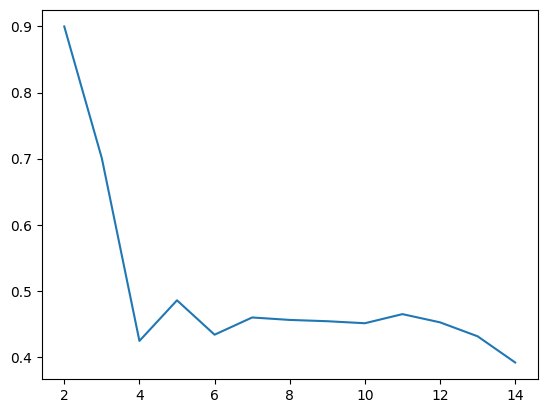

In [81]:
plt.plot(range(2,15),silhoutte_coefficients)

This is silhoutte scoring